Total number of rows: 1000000
Raw rooms_count values: rooms_count
دو              404050
یک              192083
NaN             154101
سه              138633
بدون اتاق        75898
چهار             21371
پنج یا بیشتر     13864
Name: count, dtype: int64

NaN after numeric conversion -> lat: 344392 | lon: 344392 | price: 431654 | size: 19606 | rooms: 1000000 / 1000000

Number of rows after coordinate/price/size filtering: 370133
Number of rows after removing outliers (IQR): 296112


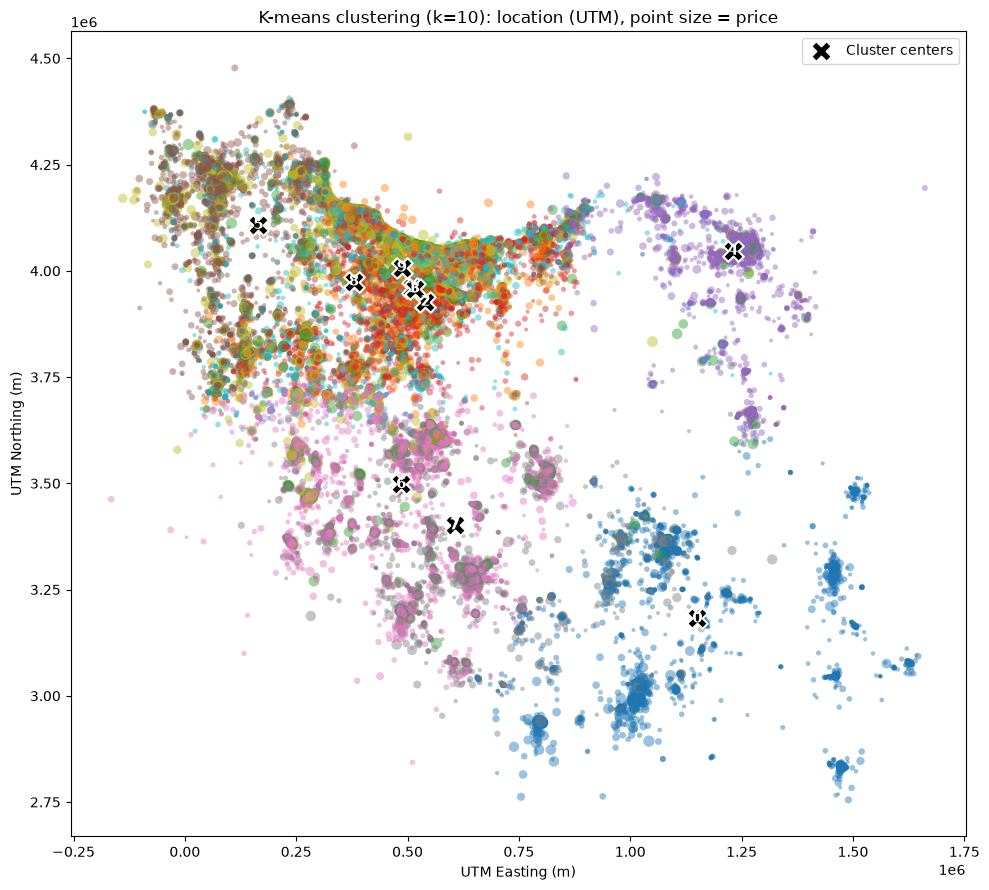

cluster
0     9010
1    46068
2    21279
3    89825
4    23185
5    26871
6    28900
7    14048
8    13359
9    23567
Name: count, dtype: int64

Average price and size of each cluster:
                price        size  rooms
cluster                                 
0        2.689524e+09  119.348946    0.0
1        4.887897e+09   95.827820    0.0
2        9.688606e+09  103.213121    0.0
3        1.868431e+09   70.740495    0.0
4        2.914540e+09  109.236187    0.0
5        2.247822e+09   94.307022    0.0
6        2.470236e+09   96.064152    0.0
7        3.906866e+09  196.646569    0.0
8        7.796226e+09  193.014148    0.0
9        1.709309e+09  202.453685    0.0


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import utm
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

PATH = r"C:\Users\vision\Desktop\bootcamp_p1\Divar.csv"

cols = [
    "location_latitude",
    "location_longitude",
    "price_value",
    "building_size",
    "rooms_count"
]

df = pd.read_csv(PATH, usecols=cols)

to_en = str.maketrans("۰۱۲۳۴۵۶۷۸۹", "0123456789")

def to_num(col):
    s = (
        col.astype(str)
        .str.translate(to_en)
        .str.replace("٫", ".", regex=False)
        .str.replace("٬", "", regex=False)
    )
    return pd.to_numeric(s, errors="coerce")

df["lat"] = to_num(df["location_latitude"])
df["lon"] = to_num(df["location_longitude"])
df["price"] = to_num(df["price_value"])
df["size"] = to_num(df["building_size"])

room_map = {
    "No room": 0,
    "One": 1,
    "Two": 2,
    "Three": 3,
    "Four": 4,
    "Five or more": 5
}

df["rooms"] = df["rooms_count"].map(room_map)

print("Total number of rows:", len(df))
print(
    "Raw rooms_count values:",
    df["rooms_count"].value_counts(dropna=False).head(15)
)

print(
    "\nNaN after numeric conversion -> lat:",
    df["lat"].isna().sum(),
    "| lon:",
    df["lon"].isna().sum(),
    "| price:",
    df["price"].isna().sum(),
    "| size:",
    df["size"].isna().sum(),
    "| rooms:",
    df["rooms"].isna().sum(),
    "/",
    len(df)
)

df["rooms"] = df["rooms"].fillna(0)

df = df.dropna(subset=["lat", "lon", "price", "size"])

df = df[
    df["lat"].between(24, 40.6)
    & df["lon"].between(43.5, 64.1)
    & (df["price"] > 0)
    & (df["size"] > 0)
]

print(
    "\nNumber of rows after coordinate/price/size filtering:",
    len(df)
)

for c in ["price", "size"]:
    q1, q3 = df[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    df = df[
        df[c].between(
            q1 - 1.5 * iqr,
            q3 + 1.5 * iqr
        )
    ]

print(
    "Number of rows after removing outliers (IQR):",
    len(df)
)

if len(df) == 0:
    raise SystemExit(
        "The dataframe became empty; check the print outputs above to see which filter caused it."
    )

easting, northing, *_ = utm.from_latlon(
    df["lat"].values,
    df["lon"].values,
    force_zone_number=39
)

df["utm_x"] = easting
df["utm_y"] = northing

X = df[
    ["utm_x", "utm_y", "price", "size", "rooms"]
].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

km = KMeans(
    n_clusters=10,
    random_state=42,
    n_init=10
)

df["cluster"] = km.fit_predict(X_scaled)

centers = scaler.inverse_transform(
    km.cluster_centers_
)

price_norm = (
    (df["price"] - df["price"].min())
    / (df["price"].max() - df["price"].min())
)

sizes = 8 + price_norm * 60

plt.figure(figsize=(10, 9))

plt.scatter(
    df["utm_x"],
    df["utm_y"],
    c=df["cluster"],
    cmap="tab10",
    s=sizes,
    alpha=0.45,
    linewidths=0
)

plt.scatter(
    centers[:, 0],
    centers[:, 1],
    c="black",
    marker="X",
    s=220,
    edgecolor="white",
    linewidth=1.5,
    label="Cluster centers",
    zorder=5
)

for i, (cx, cy, *_r) in enumerate(centers):
    plt.annotate(
        str(i),
        (cx, cy),
        fontsize=11,
        fontweight="bold",
        ha="center",
        va="center",
        color="white",
        zorder=6
    )

plt.xlabel("UTM Easting (m)")
plt.ylabel("UTM Northing (m)")
plt.title(
    "K-means clustering (k=10): location (UTM), point size = price"
)
plt.legend()
plt.tight_layout()
plt.savefig(
    "kmeans_utm_price_scatter.png",
    dpi=150
)
plt.show()

print(
    df["cluster"].value_counts().sort_index()
)

print(
    "\nAverage price and size of each cluster:"
)

print(
    df.groupby("cluster")[
        ["price", "size", "rooms"]
    ].mean()
)

k= 1  WCSS=399,468.7
k= 2  WCSS=315,855.2
k= 3  WCSS=251,057.0
k= 4  WCSS=202,749.7
k= 5  WCSS=165,308.5
k= 6  WCSS=149,605.9
k= 7  WCSS=135,560.5
k= 8  WCSS=125,081.2
k= 9  WCSS=116,142.7
k=10  WCSS=109,297.7
k=11  WCSS=102,808.9
k=12  WCSS=96,719.6
k=13  WCSS=91,227.4
k=14  WCSS=86,154.5
k=15  WCSS=82,881.0
k=16  WCSS=79,609.9
k=17  WCSS=77,057.4
k=18  WCSS=74,838.5
k=19  WCSS=72,252.0
k=20  WCSS=70,070.1


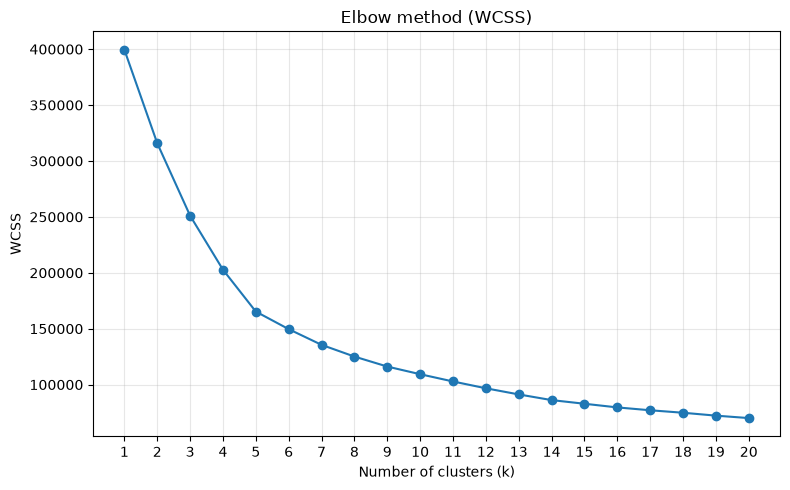

For automatic elbow detection: pip install kneed

Best k based on GridSearchCV + silhouette: 5


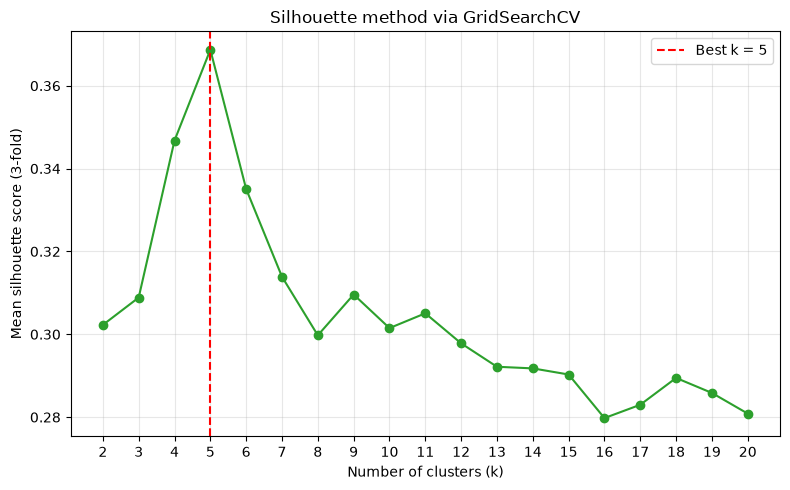

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import utm
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import silhouette_score

PATH = r"C:\Users\vision\Desktop\bootcamp_p1\Divar.csv"

cols = [
    "location_latitude",
    "location_longitude",
    "price_value",
    "building_size",
    "rooms_count"
]

df = pd.read_csv(PATH, usecols=cols)

to_en = str.maketrans("۰۱۲۳۴۵۶۷۸۹", "0123456789")

def to_num(col):
    s = (
        col.astype(str)
        .str.translate(to_en)
        .str.replace("٫", ".", regex=False)
        .str.replace("٬", "", regex=False)
    )
    return pd.to_numeric(s, errors="coerce")

df["lat"] = to_num(df["location_latitude"])
df["lon"] = to_num(df["location_longitude"])
df["price"] = to_num(df["price_value"])
df["size"] = to_num(df["building_size"])

room_map = {
    "No room": 0,
    "One": 1,
    "Two": 2,
    "Three": 3,
    "Four": 4,
    "Five or more": 5
}

df["rooms"] = df["rooms_count"].map(room_map)
df["rooms"] = df["rooms"].fillna(0)

df = df.dropna(
    subset=["lat", "lon", "price", "size"]
)

df = df[
    df["lat"].between(24, 40.6)
    & df["lon"].between(43.5, 64.1)
    & (df["price"] > 0)
    & (df["size"] > 0)
]

for c in ["price", "size"]:
    q1, q3 = df[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    df = df[
        df[c].between(
            q1 - 1.5 * iqr,
            q3 + 1.5 * iqr
        )
    ]

if len(df) == 0:
    raise SystemExit(
        "The dataframe became empty; check the filters."
    )

easting, northing, *_ = utm.from_latlon(
    df["lat"].values,
    df["lon"].values,
    force_zone_number=39
)

df["utm_x"] = easting
df["utm_y"] = northing

X = df[
    ["utm_x", "utm_y", "price", "size", "rooms"]
].copy()

X_scaled = StandardScaler().fit_transform(X)

rng = np.random.RandomState(42)

idx = rng.choice(
    len(X_scaled),
    size=min(100_000, len(X_scaled)),
    replace=False
)

X_sample = X_scaled[idx]

ks = range(1, 21)
wcss = []

for k in ks:
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    km.fit(X_sample)
    wcss.append(km.inertia_)
    print(
        f"k={k:2d}  WCSS={km.inertia_:,.1f}"
    )

plt.figure(figsize=(8, 5))

plt.plot(
    list(ks),
    wcss,
    marker="o"
)

plt.xlabel("Number of clusters (k)")
plt.ylabel("WCSS")
plt.title("Elbow method (WCSS)")
plt.xticks(list(ks))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(
    "elbow_wcss.png",
    dpi=150
)
plt.show()

try:
    from kneed import KneeLocator

    kl = KneeLocator(
        list(ks),
        wcss,
        curve="convex",
        direction="decreasing"
    )

    print(
        "Suggested k (Elbow method):",
        kl.elbow
    )

except ImportError:
    print(
        "For automatic elbow detection: pip install kneed"
    )

rng2 = np.random.RandomState(1)

idx2 = rng2.choice(
    len(X_scaled),
    size=min(20_000, len(X_scaled)),
    replace=False
)

X_sil = X_scaled[idx2]

def silhouette_scorer(estimator, X):
    labels = estimator.fit_predict(X)

    if len(set(labels)) < 2:
        return -1

    return silhouette_score(
        X,
        labels
    )

param_grid = {
    "n_clusters": range(2, 21)
}

gs = GridSearchCV(
    estimator=KMeans(
        random_state=42,
        n_init=10
    ),
    param_grid=param_grid,
    scoring=silhouette_scorer,
    cv=3
)

gs.fit(X_sil)

sil_scores = gs.cv_results_[
    "mean_test_score"
]

ks_sil = [
    p["n_clusters"]
    for p in gs.cv_results_["params"]
]

print(
    "\nBest k based on GridSearchCV + silhouette:",
    gs.best_params_["n_clusters"]
)

plt.figure(figsize=(8, 5))

plt.plot(
    ks_sil,
    sil_scores,
    marker="o",
    color="tab:green"
)

plt.axvline(
    gs.best_params_["n_clusters"],
    color="red",
    linestyle="--",
    label=f"Best k = {gs.best_params_['n_clusters']}"
)

plt.xlabel("Number of clusters (k)")
plt.ylabel("Mean silhouette score (3-fold)")
plt.title("Silhouette method via GridSearchCV")
plt.xticks(list(ks_sil))
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(
    "silhouette_gridsearch.png",
    dpi=150
)
plt.show()